In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("../../")
import data_loading as dl
from importlib import reload
reload(dl)

from microfit import run_plotter as rp
from microfit import histogram as hist

from microfit import variable_definitions as vdef
from microfit import selections

In [2]:
keep_vars = [
    "Signal_1e1p", "mc_signal_1e1p", "nu_pdg", "TrueElecIdx", "TrueLeadProtonIdx", "InFV", "HasNoMesons",
    "TrueNElec", "TrueNProt", "TrueDeltaPT", "TrueDeltaAlphaT", "TruePN", "TrueAlpha3D",
    "nproton", "npion", "npi0", "nelec", "nmuon", "isVtxInFiducial",
    "Sel_1e1p", "sel_1e1p_w_cuts", "RecoElectronCandidateIdx", "RecoLeadProtonCandidateIdx", "InFV_reco",
    "RecoElecPassMomCut", "RecoLeadProtonPassMomCut", "n_reco_tracks", "n_reco_showers",
    "RecoDeltaPT", "RecoDeltaAlphaT", "RecoPN", "RecoAlpha3D", "RecoECal", "Reco_mag_q", "RecoPL",
    "nslice", "selected", "shr_energy_tot_cali", "_opfilter_pe_beam", "_opfilter_pe_veto", "bnbdata", "extdata",
    "CosmicIPAll3D", "hits_ratio", "shrmoliereavg", "subcluster", "trkfit", "trkshrhitdist2", "tksh_distance",
    "shr_tkfit_nhits_tot", "shr_tkfit_dedx_max", "tksh_angle", "shr_trk_len", "reco_e",
    "RecoLeadProton_trk_len", "RecoLeadProton_trk_trunk_dEdx_y", "RecoLeadProton_dEdx_y_per_trklen",
    "RecoLeadProtonCandidate_trk_pid", "RecoElectronCandidate_shr_pid", "RecoElectron_conversion_dist",
    "pi0_radlen1", "pi0_radlen2", "pi0_score", "nonpi0_score", "bkg_score",
    "RecoElecE", "RecoElecModMom", "RecoElecMomX", "RecoElecMomY", "RecoElecMomZ",
    "RecoLeadProtonKE", "RecoLeadProtonModMom", "RecoLeadProtonMomX", "RecoLeadProtonMomY", "RecoLeadProtonMomZ",
]

In [ ]:
#RUN = ["1","2","3","4b","4c","4d","5"]
RUN = ["3"]

rundata, mc_weights, data_pot = dl.load_runs(
    RUN,
    data="bnb",
    loadpi0variables=False,
    loadshowervariables=True,
    loadrecoveryvars=False,
    loadsystematics=True,
    numupresel=False,
    loadnumuvariables=False,
    use_bdt=True,
    load_lee=False,
    load_nue_tki=True,
    keep_columns=keep_vars,
    blinded=True,
    load_crt_vars=False,
    enable_cache=False,
)

Loading run 3
Updating keep_columns with truth-filtering variables: {'ccnc', 'nu_pdg'}
/pnfs/uboone/persistent/users/cthorpe/PELEE_2023/run3/bnb_beam_off_peleeTuple_uboone_v08_00_00_70_run3.root


In [ ]:
run_combo = "Run"
for run in RUN:
    run_combo += run

In [ ]:
from microfit import selections as sel

selection = "None"
preselection = "OneP_new"
query = f"{sel.preselection_categories[preselection]['query']}" #" and {sel.selection_categories[selection]['query']}"
#sel_title = f"{sel.selection_categories[selection]['title']}"

all_mc = pd.concat([df for k, df in rundata.items() if k!='data'])
sel_mc = all_mc.query(query, engine='python')
is_sig = sel_mc['category_1e1p'] == 12
sel_sig = sel_mc.loc[is_sig]
sel_bkg = sel_mc.loc[~is_sig]


In [3]:
# Selected signal - pi0 & non-pi0

H, xedges, yedges = np.histogram2d(sel_sig["pi0_score"], sel_sig["nonpi0_score"], bins=20, weights=sel_sig["weights"], range=[[0,1],[0,1]])
X, Y = np.meshgrid(xedges,yedges)
plt.pcolormesh(X, Y, H.T, shading='flat') #, norm=LogNorm())
plt.colorbar()
plt.xlabel('BDT $\\pi^{0}$ score')
plt.ylabel('BDT non-$\\pi^{0}$ score')
    
plt.title(f"Selected Signal Events")
plt.savefig(f'plots/reco_study/bdt_scores/2D_sig_pi0score_nonpi0score_{preselection}_{selection}_{run_combo}.pdf', bbox_inches='tight')
plt.savefig(f'plots/reco_study/bdt_scores/2D_sig_pi0score_nonpi0score_{preselection}_{selection}_{run_combo}.png', bbox_inches='tight')
plt.show()
plt.clf()

NameError: name 'sel_sig' is not defined

OSError: [Errno 127] Key has expired: '/nashome/m/mmoudgal/.ipython'

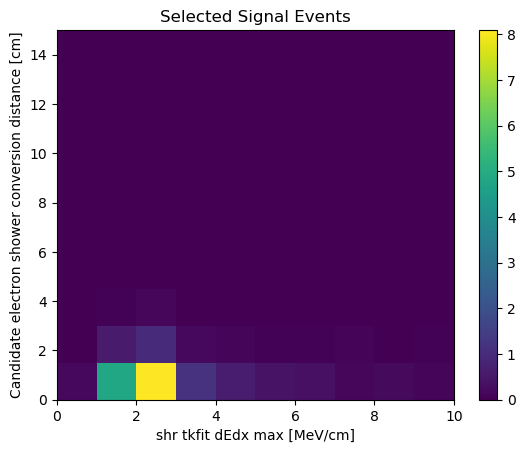

In [13]:
# Selected signal - pi0 & 0p

H, xedges, yedges = np.histogram2d(sel_sig["pi0_score"], sel_sig["bkg_score"], bins=20, weights=sel_sig["weights"], range=[[0,1],[0,1]])
X, Y = np.meshgrid(xedges,yedges)
plt.pcolormesh(X, Y, H.T, shading='flat') #, norm=LogNorm())
plt.colorbar()
plt.xlabel('BDT $\\pi^{0}$ score')
plt.ylabel('1e0p BDT score')
    
plt.title(f"Selected Signal Events")
plt.savefig(f'plots/reco_study/bdt_scores/2D_sig_pi0score_0pscore_{preselection}_{selection}_{run_combo}.pdf', bbox_inches='tight')
plt.savefig(f'plots/reco_study/bdt_scores/2D_sig_pi0score_0pscore_{preselection}_{selection}_{run_combo}.png', bbox_inches='tight')
plt.show()
plt.clf()

OSError: [Errno 127] Key has expired: '/nashome/m/mmoudgal/.ipython'

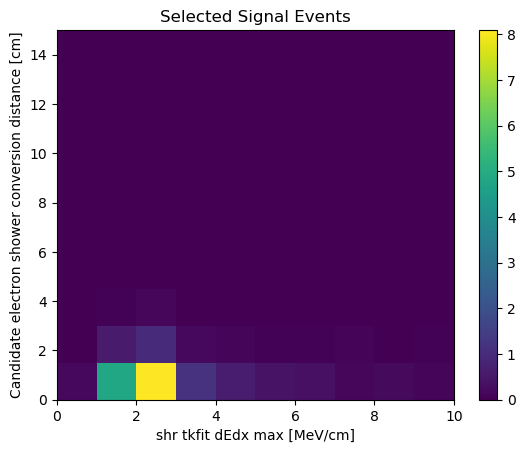

In [13]:
# Selected signal - nonpi0 & 0p

H, xedges, yedges = np.histogram2d(sel_sig["nonpi0_score"], sel_sig["bkg_score"], bins=20, weights=sel_sig["weights"], range=[[0,1],[0,1]])
X, Y = np.meshgrid(xedges,yedges)
plt.pcolormesh(X, Y, H.T, shading='flat') #, norm=LogNorm())
plt.colorbar()
plt.xlabel('BDT non-$\\pi^{0}$ score')
plt.ylabel('1e0p BDT score')
    
plt.title(f"Selected Signal Events")
plt.savefig(f'plots/reco_study/bdt_scores/2D_sig_nonpi0score_0pscore_{preselection}_{selection}_{run_combo}.pdf', bbox_inches='tight')
plt.savefig(f'plots/reco_study/bdt_scores/2D_sig_nonpi0score_0pscore_{preselection}_{selection}_{run_combo}.png', bbox_inches='tight')
plt.show()
plt.clf()

In [ ]:
# Selected background - pi0 & non-pi0

H, xedges, yedges = np.histogram2d(sel_bkg["pi0_score"], sel_bkg["nonpi0_score"], bins=20, weights=sel_bkg["weights"], range=[[0,1],[0,1]])
X, Y = np.meshgrid(xedges,yedges)
plt.pcolormesh(X, Y, H.T, shading='flat') #, norm=LogNorm())
plt.colorbar()
plt.xlabel('BDT $\\pi^{0}$ score')
plt.ylabel('BDT non-$\\pi^{0}$ score')
    
plt.title(f"Selected Background Events")
plt.savefig(f'plots/reco_study/bdt_scores/2D_bkg_pi0score_nonpi0score_{preselection}_{selection}_{run_combo}.pdf', bbox_inches='tight')
plt.savefig(f'plots/reco_study/bdt_scores/2D_bkg_pi0score_nonpi0score_{preselection}_{selection}_{run_combo}.png', bbox_inches='tight')
plt.show()
plt.clf()

In [ ]:
# Selected background - pi0 & 0p

H, xedges, yedges = np.histogram2d(sel_bkg["pi0_score"], sel_bkg["bkg_score"], bins=20, weights=sel_bkg["weights"], range=[[0,1],[0,1]])
X, Y = np.meshgrid(xedges,yedges)
plt.pcolormesh(X, Y, H.T, shading='flat') #, norm=LogNorm())
plt.colorbar()
plt.xlabel('BDT $\\pi^{0}$ score')
plt.ylabel('1e0p BDT score')
    
plt.title(f"Selected Background Events")
plt.savefig(f'plots/reco_study/bdt_scores/2D_bkg_pi0score_0pscore_{preselection}_{selection}_{run_combo}.pdf', bbox_inches='tight')
plt.savefig(f'plots/reco_study/bdt_scores/2D_bkg_pi0score_0pscore_{preselection}_{selection}_{run_combo}.png', bbox_inches='tight')
plt.show()
plt.clf()

In [ ]:
# Selected background - nonpi0 & 0p

H, xedges, yedges = np.histogram2d(sel_bkg["nonpi0_score"], sel_bkg["bkg_score"], bins=20, weights=sel_bkg["weights"], range=[[0,1],[0,1]])
X, Y = np.meshgrid(xedges,yedges)
plt.pcolormesh(X, Y, H.T, shading='flat') #, norm=LogNorm())
plt.colorbar()
plt.xlabel('BDT non-$\\pi^{0}$ score')
plt.ylabel('1e0p BDT score')
    
plt.title(f"Selected Background Events")
plt.savefig(f'plots/reco_study/bdt_scores/2D_bkg_nonpi0score_0pscore_{preselection}_{selection}_{run_combo}.pdf', bbox_inches='tight')
plt.savefig(f'plots/reco_study/bdt_scores/2D_bkg_nonpi0score_0pscore_{preselection}_{selection}_{run_combo}.png', bbox_inches='tight')
plt.show()
plt.clf()